<a href="https://colab.research.google.com/github/peakodev/data_science/blob/main/home_03/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдаття

Дане домашнє завдання буде повністю пов'язане з лінійною регресією та її реалізацією. Отож розіб'ємо наше домашнє завдання на декілька частин:

1. напишіть функцію гіпотези лінійної регресії у векторному вигляді;
2. створіть функцію для обчислення функції втрат у векторному вигляді;
3. реалізуйте один крок градієнтного спуску;
4. знайдіть найкращі параметри w для датасету прогнозуючу ціну на будинок залежно від площі, кількості ванних кімнат та кількості спалень;
5. знайдіть ці ж параметри за допомогою аналітичного рішення;
порівняйте отримані результати.


Дз повинно бути виконано у Jupyter Nootebook,(або Google Colab) і задеплоїне на Гітхаб у вигляді файлу .ipynb.

# 1. Напишіть функцію гіпотези лінійної регресії у векторному вигляді

In [1]:
import numpy as np

def hypothesis(X, weights):
    return np.dot(X, weights)

# 2. Створіть функцію для обчислення функції втрат у векторному вигляді

$$
J(\theta) = \frac{1}{2m} (X\theta - y)^T (X\theta - y)
$$


In [2]:
import numpy as np

def compute_loss(X, y, weights):
    """
    Compute the loss with a bias term for linear regression.

    Parameters:
    X: numpy.ndarray, shape (m, n)
        Matrix of input features, where m is the number of examples and n is the number of features.
    y: numpy.ndarray, shape (m, 1)
        Vector of true values.
    weights: numpy.ndarray, shape (n+1, 1)
        Vector of parameters including the bias term.

    Returns:
    float
        The mean squared error loss.
    """

    # number of examples
    n_samples = len(y)

    # Add a column of ones to X to account for the bias term
    X = np.hstack([np.ones((n_samples, 1)), X])

    # Compute the predictions
    predictions = hypothesis(X, weights)
    print(f"predictions: \n{predictions}")

    # Compute the errors
    difference = predictions - y

    # Compute the mean squared error loss (MSE)
    cost = (1 / (2 * n_samples)) * np.dot(difference.T, difference)

    return cost

In [3]:
# Test cases
def test_compute_loss():
    # Test case 1: Simple example with known weights and bias
    X_test = np.array([[1], [2], [3], [4]])
    y_test = np.array([[3], [5], [7], [9]])  # y = 2x + 1
    weights_test = np.array([[1], [2]])      # bias = 1, weight = 2

    print(f"X_test: \n{X_test}")
    print(f"y_test: \n{y_test}")
    print(f"weights_test: \n{weights_test}")

    loss = compute_loss(X_test, y_test, weights_test)
    print(f"Computed loss: {loss}")

    # Expected MSE for this simple case should be close to 0, since y = 2x + 1 is perfectly predicted
    assert np.isclose(loss, 0), f"Test failed! Expected loss close to 0, but got {loss}"

    print("Test passed!")

# Run the test
test_compute_loss()

X_test: 
[[1]
 [2]
 [3]
 [4]]
y_test: 
[[3]
 [5]
 [7]
 [9]]
weights_test: 
[[1]
 [2]]
predictions: 
[[3.]
 [5.]
 [7.]
 [9.]]
Computed loss: [[0.]]
Test passed!


# 3. Реалізуйте один крок градієнтного спуску

In [4]:
def gradient_descent_step(X, y, weights, lr):
    n_samples = len(y)

    # predicted value with the current weights
    predicted = hypothesis(X, weights)

    difference = predicted - y

    # compute gradients
    dw = (1 / n_samples) * np.dot(X.T, difference)

    # update parameters
    weights -= lr * dw

    # cost value of the current iteration with 1/(2 * n_samples)
    cost = (1 / (2 * n_samples)) * np.dot(difference.T, difference)

    return cost, weights

In [5]:
# Test function for gradient_descent_step
def test_gradient_descent_step():
    # Initialize synthetic data
    X_test = np.array([[1], [2], [3], [4]])
    y_test = np.array([[3], [5], [7], [9]])  # y = 2x + 1

    # Initialize weights as floats to prevent type issues
    initial_weights = np.array([[0.0], [0.0]])  # start with weights and bias as 0.0
    learning_rate = 0.1

    # Add a column of ones to X_test to account for the bias term
    n_samples = X_test.shape[0]
    X_bias = np.hstack([np.ones((n_samples, 1)), X_test])

    print("Initial Weights:", initial_weights.T)
    print("X_bias:", X_bias)
    print("y_test:", y_test.T)

    # Perform a gradient descent step
    cost, updated_weights = gradient_descent_step(X_bias, y_test, initial_weights, learning_rate)

    print("Updated Weights:", updated_weights.T)
    print("Cost after gradient descent step:", cost)

    # Check if the weights are updated towards expected values
    expected_weights = np.array([[1.0], [2.0]])  # Ideal weights for y = 2x + 1
    close_enough = np.allclose(updated_weights, expected_weights, atol=1.0)  # Allow some tolerance

    assert close_enough, "Test failed! Weights did not update towards expected values."

    print("Test passed!")

# Run the test
test_gradient_descent_step()

Initial Weights: [[0. 0.]]
X_bias: [[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]]
y_test: [[3 5 7 9]]
Updated Weights: [[0.6  1.75]]
Cost after gradient descent step: [[20.5]]
Test passed!


# 4. Знайдіть найкращі параметри w для датасету прогнозуючу ціну на будинок залежно від площі, кількості ванних кімнат та кількості спалень

In [6]:
import numpy as np

class MyLinearRegression:

    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.costs = []

    def gradient_descent(self, X, y):
        n_samples = X.shape[0]

        for _ in range(self.n_iters):
            # predicted value with the current weights
            y_predicted = np.dot(X, self.weights)

            difference = y_predicted - y

            # compute gradients
            dw = (1 / n_samples) * np.dot(X.T, difference)

            # update parameters
            self.weights -= self.lr * dw

            # cost value of the current iteration with 1/(2 * n_samples)
            cost = (1 / (2 * n_samples)) * np.dot(difference.T, difference)
            self.costs.append(cost)

    def fit(self, X, y):
        # add a column of ones to X to include the bias term
        n_samples, n_features = X.shape
        X_bias = np.hstack([np.ones((n_samples, 1)), X])
        self.weights = np.zeros(n_features + 1)  # initialize weights with bias term

        # reshaping target variable (m,1) to (m,)
        y = y.reshape(y.shape[0])

        print(f"X_bias --> shape: {X_bias.shape}")
        print(f"y      --> shape: {y.shape}")
        print(f"THETA  --> shape: {self.weights.shape}")

        self.gradient_descent(X_bias, y)

    def predict(self, X):
        # add a column of ones to X to include the bias term for prediction
        n_samples = X.shape[0]
        X_bias = np.hstack([np.ones((n_samples, 1)), X])

        y_approximated = np.dot(X_bias, self.weights)
        return y_approximated

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Housing.csv')

In [10]:
normalized_df = df.copy(deep=True)
normalized_df.area = (df.area - df.area.mean()) / df.area.std()
normalized_df.price = (df.price - df.price.mean()) / df.price.std()
normalized_df.bedrooms = (df.bedrooms - df.bedrooms.mean()) / df.bedrooms.std()
normalized_df.bathrooms = (df.bathrooms - df.bathrooms.mean()) / df.bathrooms.std()

X_bias --> shape: (545, 4)
y      --> shape: (545,)
THETA  --> shape: (4,)


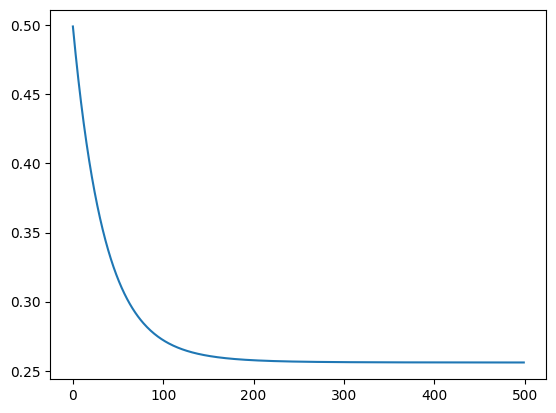

In [13]:
X_train = np.array(normalized_df[['area', 'bedrooms', 'bathrooms']])
y_train = np.array(normalized_df['price'])

linear_regression_model = MyLinearRegression(learning_rate=0.01, n_iters=500)
linear_regression_model.fit(X_train, y_train)

sns.lineplot(x=range(linear_regression_model.n_iters), y=linear_regression_model.costs)
plt.show()

In [16]:
linear_regression_model.weights

array([2.80550303e-16, 4.37267583e-01, 1.64993836e-01, 3.69079904e-01])

In [21]:
# test
area, bedrooms, bathrooms = 150, 3, 2

test_area = (area - df.area.mean()) / df.area.std()
test_bedrooms = (bedrooms - df.bedrooms.mean()) / df.bedrooms.std()
test_bathrooms = (bathrooms - df.bathrooms.mean()) / df.bathrooms.std()

normalized_prediction = linear_regression_model.predict(np.array([[test_area, test_bedrooms, test_bathrooms]]))
predicted_price = normalized_prediction[0] * df.price.std() + df.price.mean()
predicted_price

3877337.7718616743